In [1]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional
import matplotlib.pyplot as plt

def create_sequence(dataset):
  sequences = []
  labels = []

  start_idx = 0

  for stop_idx in range(50,len(dataset)): 
    sequences.append(dataset.iloc[start_idx:stop_idx])
    labels.append(dataset.iloc[stop_idx])
    start_idx += 1
  
  return (np.array(sequences),np.array(labels))


sqlite_database = 'database/base.db'
sqlite_conn = sqlite3.connect(sqlite_database)
sqlite_select_query = f"""SELECT * FROM instrument_history_minute WHERE date > '2022-01-03' and date < '2022-02-01' """
sqlquery_pd = pd.read_sql_query(sqlite_select_query,sqlite_conn)
gstock_data = pd.DataFrame(sqlquery_pd, columns = ['date', 'open','close'])
gstock_data['date'] = gstock_data['date'].apply(lambda x: datetime.strptime(x,'%Y-%m-%d %H:%M:%S'))
#gstock_data ['date'] = pd.<a onclick="parent.postMessage({'referent':'.pandas.to_datetime'}, '*')">to_datetime(gstock_data ['date'].apply(lambda x: x.split()[0])) 
gstock_data .set_index('date',drop=True,inplace=True) 
# gstock_data .head()
gstock_data .info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7500 entries, 2022-01-03 09:15:00 to 2022-01-31 15:29:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    7500 non-null   float64
 1   close   7500 non-null   float64
dtypes: float64(2)
memory usage: 175.8 KB


In [2]:
Ms = MinMaxScaler()
gstock_data [gstock_data .columns] = Ms.fit_transform(gstock_data )
training_size = round(len(gstock_data ) * 0.80)
train_data = gstock_data [:training_size]
test_data  = gstock_data [training_size:]

In [3]:
train_seq, train_label = create_sequence(train_data)
test_seq, test_label = create_sequence(test_data)

In [4]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape = (train_seq.shape[1], train_seq.shape[2])))

model.add(Dropout(0.1)) 
model.add(LSTM(units=50))

model.add(Dense(2))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 50)            10600     
                                                                 
 dropout (Dropout)           (None, 50, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 2)                 102       
                                                                 
Total params: 30,902
Trainable params: 30,902
Non-trainable params: 0
_________________________________________________________________


In [5]:
model.fit(train_seq, train_label, epochs=80,validation_data=(test_seq, test_label), verbose=1)
test_predicted = model.predict(test_seq)

Epoch 1/80
186/186 [==============================] - 8s 28ms/step - loss: 0.0130 - mean_absolute_error: 0.0549 - val_loss: 5.5203e-04 - val_mean_absolute_error: 0.0158
Epoch 2/80
186/186 [==============================] - 4s 23ms/step - loss: 6.0636e-04 - mean_absolute_error: 0.0186 - val_loss: 5.3350e-04 - val_mean_absolute_error: 0.0155
Epoch 3/80
186/186 [==============================] - 5s 25ms/step - loss: 5.6000e-04 - mean_absolute_error: 0.0178 - val_loss: 5.1656e-04 - val_mean_absolute_error: 0.0152
Epoch 4/80
186/186 [==============================] - 5s 26ms/step - loss: 4.9663e-04 - mean_absolute_error: 0.0167 - val_loss: 6.3717e-04 - val_mean_absolute_error: 0.0184
Epoch 5/80
186/186 [==============================] - 5s 25ms/step - loss: 4.8792e-04 - mean_absolute_error: 0.0166 - val_loss: 5.6928e-04 - val_mean_absolute_error: 0.0165
Epoch 6/80
186/186 [==============================] - 5s 26ms/step - loss: 4.4123e-04 - mean_absolute_error: 0.0157 - val_loss: 4.7161e-04 

186/186 [==============================] - 4s 24ms/step - loss: 9.2519e-05 - mean_absolute_error: 0.0072 - val_loss: 9.6751e-05 - val_mean_absolute_error: 0.0057
Epoch 49/80
186/186 [==============================] - 4s 23ms/step - loss: 7.1799e-05 - mean_absolute_error: 0.0061 - val_loss: 1.1302e-04 - val_mean_absolute_error: 0.0067
Epoch 50/80
186/186 [==============================] - 4s 24ms/step - loss: 6.9768e-05 - mean_absolute_error: 0.0060 - val_loss: 9.0657e-05 - val_mean_absolute_error: 0.0053
Epoch 51/80
186/186 [==============================] - 4s 24ms/step - loss: 7.5738e-05 - mean_absolute_error: 0.0063 - val_loss: 1.0366e-04 - val_mean_absolute_error: 0.0066
Epoch 52/80
186/186 [==============================] - 4s 24ms/step - loss: 7.5669e-05 - mean_absolute_error: 0.0063 - val_loss: 1.0719e-04 - val_mean_absolute_error: 0.0067
Epoch 53/80
186/186 [==============================] - 4s 24ms/step - loss: 7.2110e-05 - mean_absolute_error: 0.0062 - val_loss: 8.7420e-05 - 

In [6]:
test_inverse_predicted = Ms.inverse_transform(test_predicted)

In [48]:
gsstock_actual = gstock_data.tail(375).copy()
gsstock_predict_all = pd.DataFrame(test_inverse_predicted,columns=['open_predicted','close_predicted'], index=gstock_data .iloc[-1450:].index)
gsstock_predict = gsstock_predict_all.tail(375).copy()

In [52]:
gs_slic_data = pd.concat((gsstock_actual,gsstock_predict), axis=1)
gs_slic_data[['open','close']] = Ms.inverse_transform(gs_slic_data[['open','close']])
gs_slic_data

,open,close,open_predicted,close_predicted
date,,,,
2022-01-31 09:15:00,38091.80,38112.65,37699.984375,37703.613281
2022-01-31 09:16:00,38119.20,38186.45,38147.910156,38159.207031
2022-01-31 09:17:00,38185.65,38131.65,38171.382812,38177.679688
2022-01-31 09:18:00,38137.25,38145.50,38143.539062,38145.097656
2022-01-31 09:19:00,38146.95,38158.85,38159.687500,38159.742188
...,...,...,...,...
2022-01-31 15:25:00,37947.50,37971.50,37963.152344,37965.738281
2022-01-31 15:26:00,37973.00,37951.45,37986.644531,37990.183594
2022-01-31 15:27:00,37955.80,37963.05,37967.066406,37970.085938


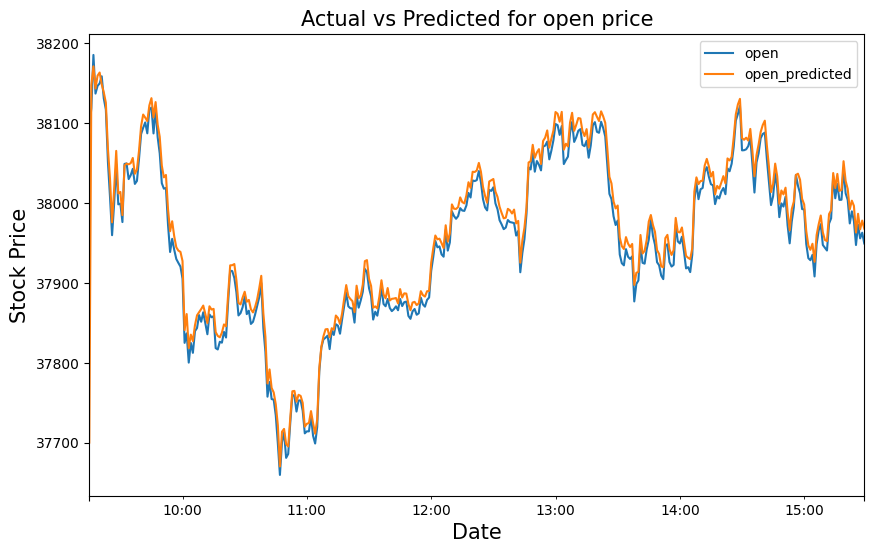

In [50]:
gs_slic_data[['open','open_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for open price',size=15)
plt.show()

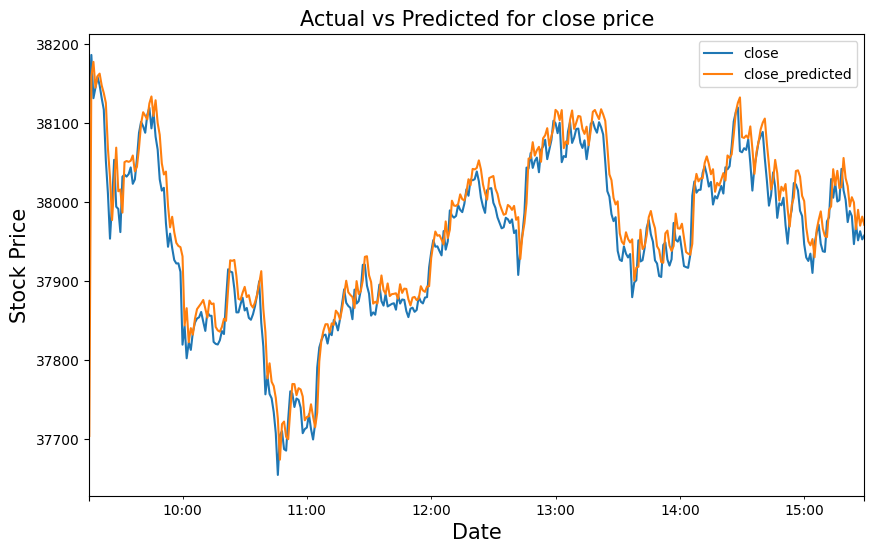

In [51]:
gs_slic_data[['close','close_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for close price',size=15)
plt.show()